In [1]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


=== HASIL KASUS 1 ===
Persamaan Model Garis: y = 0.200 + 1.950x


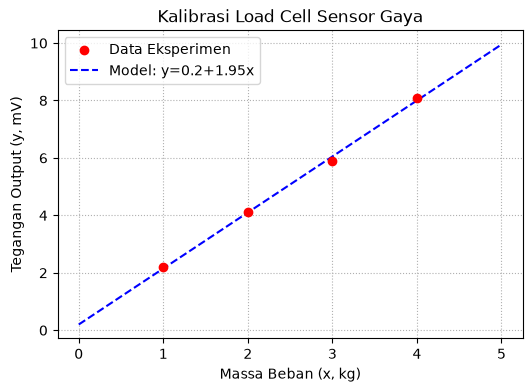

In [2]:
# KASUS 1: KALIBRASI SENSOR GAYA (REGRESI LINEAR)

# 1. Definisikan Data Eksperimen
x_gaya = np.array([1, 2, 3, 4])
y_tegangan = np.array([2.2, 4.1, 5.9, 8.1])
n1 = len(x_gaya)

# 2. Hitung Parameter Menggunakan Formulasi Eksplisit
sum_x = np.sum(x_gaya)
sum_y = np.sum(y_tegangan)
sum_x2 = np.sum(x_gaya**2)
sum_xy = np.sum(x_gaya * y_tegangan)

a1 = (n1 * sum_xy - sum_x * sum_y) / (n1 * sum_x2 - sum_x**2)
a0 = np.mean(y_tegangan) - a1 * np.mean(x_gaya)

print("=== HASIL KASUS 1 ===")
print(f"Persamaan Model Garis: y = {a0:.3f} + {a1:.3f}x")

# 3. Visualisasi Hasil Kalibrasi
plt.figure(figsize=(6, 4))
plt.scatter(x_gaya, y_tegangan, color='red', label='Data Eksperimen', zorder=5)
x_fit = np.linspace(0, 5, 100)
y_fit = a0 + a1 * x_fit
plt.plot(x_fit, y_fit, color='blue', linestyle='--', label=f'Model: y={a0:.1f}+{a1:.2f}x')
plt.title('Kalibrasi Load Cell Sensor Gaya')
plt.xlabel('Massa Beban (x, kg)')
plt.ylabel('Tegangan Output (y, mV)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

In [3]:
# KASUS 2: KORELASI PERPINDAHAN KALOR KONVEKSI (REGRESI MULTIVARIABEL)

# 1. Sampel Data Eksperimen Aliran Fluida (Nu, Re, Pr)
Re = np.array([1200, 2500, 5000, 8500, 12000])
Pr = np.array([0.71, 0.71, 1.00, 4.30, 7.00])
Nu = np.array([18.5, 26.8, 42.5, 98.2, 145.0])

# 2. Transformasi Linear (Logaritma Natural)
y_mult = np.log(Nu)
x1_mult = np.log(Re)
x2_mult = np.log(Pr)
n2 = len(Nu)

# 3. Menyusun Matriks Desain X dan Vektor Target Y
X = np.vstack([np.ones(n2), x1_mult, x2_mult]).T
Y = y_mult.reshape(-1, 1)

# 4. Menyelesaikan Persamaan Normal: (X^T * X) * A = X^T * Y
A = np.linalg.inv(X.T @ X) @ X.T @ Y

# 5. Mengembalikan ke Konstanta Fisik Asli
C_konstanta = np.exp(A[0][0])
m_eksponen = A[1][0]
n_eksponen = A[2][0]

print("=== HASIL KASUS 2 ===")
print(f"Koefisien Matriks A (a0, a1, a2): {A.flatten()}")
print(f"Konstanta C : {C_konstanta:.4f}")
print(f"Eksponen m (Reynolds) : {m_eksponen:.4f}")
print(f"Eksponen n (Prandtl)  : {n_eksponen:.4f}")
print(f"Formala Empiris: Nu = {C_konstanta:.3f} * Re^{m_eksponen:.3f} * Pr^{n_eksponen:.3f}")

# 6. Evaluasi Koefisien Determinasi (R^2)
y_pred = X @ A
St = np.sum((y_mult - np.mean(y_mult))**2)
Sr = np.sum((y_mult - y_pred.flatten())**2)
R2 = (St - Sr) / St
print(f"Koefisien Determinasi (R^2): {R2:.5f}")

=== HASIL KASUS 2 ===
Koefisien Matriks A (a0, a1, a2): [-0.39816166  0.4875497   0.40287691]
Konstanta C : 0.6716
Eksponen m (Reynolds) : 0.4875
Eksponen n (Prandtl)  : 0.4029
Formala Empiris: Nu = 0.672 * Re^0.488 * Pr^0.403
Koefisien Determinasi (R^2): 0.99985
